<a href="https://colab.research.google.com/github/jeeva477/DL_Skill_Tracker/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

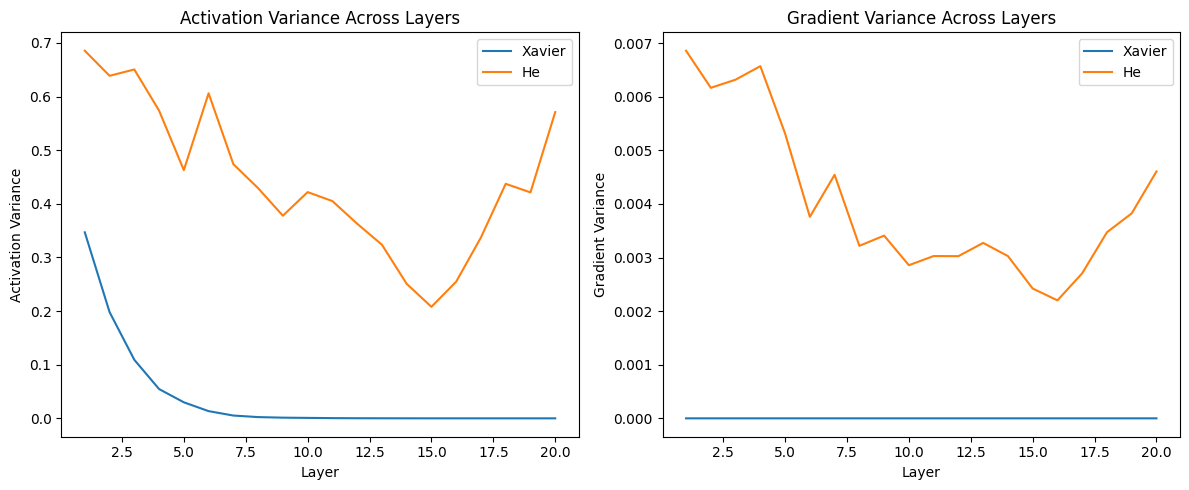

Xavier final activation variance: 7.81706944508187e-07
He final activation variance: 0.5709418654441833
Xavier final gradient variance: 1.812175831616969e-08
He final gradient variance: 0.0046073757112026215


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -------------------------------
# Configuration
# -------------------------------
torch.manual_seed(42)

input_dim = 128
hidden_dim = 128
num_layers = 20
batch_size = 64

# -------------------------------
# Build deep MLP
# -------------------------------
def build_network(init_type):
    layers = []

    for _ in range(num_layers):
        linear = nn.Linear(hidden_dim, hidden_dim)

        if init_type == "xavier":
            nn.init.xavier_uniform_(linear.weight)
        else:
            nn.init.kaiming_uniform_(linear.weight, nonlinearity="relu")

        nn.init.zeros_(linear.bias)

        layers.append(linear)
        layers.append(nn.ReLU())

    return nn.Sequential(*layers)

# -------------------------------
# Create networks
# -------------------------------
xavier_net = build_network("xavier")
he_net = build_network("he")

# -------------------------------
# Input
# -------------------------------
X = torch.randn(batch_size, hidden_dim)

# -------------------------------
# Forward diagnostic
# -------------------------------
def activation_statistics(model, X):

    means = []
    variances = []

    A = X

    for layer in model:

        A = layer(A)

        if isinstance(layer, nn.ReLU):
            means.append(A.mean().item())
            variances.append(A.var().item())

    return means, variances

# -------------------------------
# Gradient diagnostic
# -------------------------------
def gradient_statistics(model, X):

    activations = [X]

    A = X

    # Store activations
    for layer in model:
        A = layer(A)
        activations.append(A)

    dA = torch.randn_like(activations[-1])

    grad_vars = []

    # Manual gradient propagation
    for i in reversed(range(len(model))):

        layer = model[i]

        if isinstance(layer, nn.ReLU):
            dA = dA * (activations[i + 1] > 0).float()

        elif isinstance(layer, nn.Linear):
            dW = activations[i].T @ dA / activations[i].shape[0]
            grad_vars.append(dW.var().item())
            dA = dA @ layer.weight

    grad_vars.reverse()

    return grad_vars

# -------------------------------
# Collect statistics
# -------------------------------
x_mean, x_var = activation_statistics(xavier_net, X)
h_mean, h_var = activation_statistics(he_net, X)

x_grad = gradient_statistics(xavier_net, X)
h_grad = gradient_statistics(he_net, X)

# -------------------------------
# Plot activation variance
# -------------------------------
layers = range(1, num_layers + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(layers, x_var, label="Xavier")
plt.plot(layers, h_var, label="He")
plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("Activation Variance Across Layers")
plt.legend()

plt.subplot(1,2,2)
plt.plot(layers, x_grad, label="Xavier")
plt.plot(layers, h_grad, label="He")
plt.xlabel("Layer")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance Across Layers")
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------
# Numerical summary
# -------------------------------
print("Xavier final activation variance:", x_var[-1])
print("He final activation variance:", h_var[-1])

print("Xavier final gradient variance:", x_grad[-1])
print("He final gradient variance:", h_grad[-1])